# Project Milestone Two: Modeling and Feature Engineering

### Overview

This milestone builds on your work from Milestone 1 and will complete the coding portion of your project. You will:

1. Pick 3 modeling algorithms from those we have studied.
2. Evaluate baseline models using default settings.
3. Engineer new features and re-evaluate models.
4. Use feature selection techniques and re-evaluate.
5. Fine-tune for optimal performance.
6. Select your best model and report on your results. 

You must do all work in this notebook and upload to your team leader's account in Gradescope. There is no
Individual Assessment for this Milestone. 


In [1]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import (
    BaggingRegressor, 
    RandomForestRegressor, 
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

# Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))


### Prelude: Load your Preprocessed Dataset from Milestone 1

In Milestone 1, you handled missing values, encoded categorical features, and explored your data. Before you begin this milestone, you’ll need to load that cleaned dataset and prepare it for modeling. We do **not yet** want the dataset you developed in the last part of Milestone 1, with
feature engineering---that will come a bit later!

Here’s what to do:

1. Return to your Milestone 1 notebook and rerun your code through Part 3, where your dataset was fully cleaned (assume it’s called `df_cleaned`).

2. **Save** the cleaned dataset to a file by running:

>   df_cleaned.to_csv("zillow_cleaned.csv", index=False)

3. Switch to this notebook and **load** the saved data:

>   df = pd.read_csv("zillow_cleaned.csv")

4. Create a **train/test split** using `train_test_split`.  
   
6. **Standardize** the features (but not the target!) using **only the training data.** This ensures consistency across models without introducing data leakage from the test set:

>   scaler = StandardScaler()   
>   X_train_scaled = scaler.fit_transform(X_train)    
  
**Notes:** 

- You will have to redo the scaling step if you introduce new features (which have to be scaled as well).


In [2]:
# =============================================================================
# Prelude: Load the cleaned dataset from Milestone 1 (Parts 3A-3E) and prepare
# for modeling. No feature engineering yet — that comes in Part 2.
# =============================================================================

df_cleaned = pd.read_csv("zillow_cleaned.csv")
print(f"Cleaned dataset: {df_cleaned.shape}")

target = 'taxvaluedollarcnt'

# =============================================================================
# Train/Test Split and Scaling
# =============================================================================
X = df_cleaned.drop(columns=[target])
y = df_cleaned[target]

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=random_state
)
print(f"\nTrain set: {X_train.shape}, Test set: {X_test.shape}")

# Standardize features using only training data (no data leakage)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
  scaler.fit_transform(X_train),
  columns=X_train.columns,
  index=X_train.index
)
X_test_scaled = pd.DataFrame(
  scaler.transform(X_test),
  columns=X_test.columns,
  index=X_test.index
)

print(f"Scaling complete. Features: {X_train_scaled.shape[1]}")
print(f"Target range: ${y_train.min():,.0f} - ${y_train.max():,.0f}")

Cleaned dataset: (72332, 62)

Train set: (57865, 61), Test set: (14467, 61)
Scaling complete. Features: 61
Target range: $1,000 - $1,112,216


### Part 1: Picking Three Models and Establishing Baselines [6 pts]

Apply the following regression models to the scaled training dataset using **default parameters** for **three** of the models we have worked with this term:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Bagging
- Random Forest
- Gradient Boosting Trees

For each of the three models:
- Use **repeated cross-validation** (e.g., 5 folds, 5 repeats).
- Report the **mean and standard deviation of CV MAE Score**. 


In [3]:
# =============================================================================
# Part 1: Baseline Setup — Repeated CV and results storage
# =============================================================================
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)
baseline_results = {}

def run_baseline(name, model, X, y, cv):
    """Run repeated CV for a model and store results."""
    start = time.time()
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
    mae_scores = -scores
    elapsed = time.time() - start
    baseline_results[name] = {'mean_mae': mae_scores.mean(), 'std_mae': mae_scores.std(), 'time': elapsed}
    print(f"{name}:")
    print(f"  CV MAE = ${mae_scores.mean():,.2f} ± ${mae_scores.std():,.2f}")
    print(f"  Time: {format_hms(elapsed)}\n")

#### Baseline: Ridge Regression

Plain Linear Regression (OLS) produced a mean MAE in the trillions, but investigation showed that 24 of 25 cross-validation folds were normal (`~$149K MAE`) while one fold blew up to `$33` trillion, dragging up the average. This happens because our dataset has columns that measure the same thing (e.g., `calculatedfinishedsquarefeet` and `finishedsquarefeet12` both capture square footage, and `bathroomcnt`, `calculatedbathnbr`, and `fullbathcnt` all count bathrooms). When features are nearly identical, OLS can't figure out how to split credit between them, so the weights swing to extreme values in certain folds.

We attempted to fix this by dropping the near-duplicate columns identified in Milestone 1's 3A Discussion, where we noted these redundancies but deferred removal to compare their behavior in Parts 4-5. However, even after dropping them, OLS still produced blown-up folds (now two instead of one), suggesting subtler collinearity remains among other features in the dataset.

Rather than continuing to hunt down and remove every collinear feature pair which risks losing potentially useful information, we chose Ridge Regression as our linear baseline. Ridge adds an L2 penalty that keeps coefficients small and stable even in the presence of multicollinearity, giving us consistent results across all CV folds without needing to alter our feature set. This makes it a drop-in replacement for OLS that is more robust to the structure of our data.

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

model = LinearRegression()
scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='neg_mean_absolute_error')
print("Per-fold MAE:", -scores)

Per-fold MAE: [1.48051796e+05 1.47844949e+05 1.51253675e+05 1.49480181e+05
 3.34670230e+13 1.48267057e+05 1.49131151e+05 1.50310764e+05
 1.51280926e+05 1.48987680e+05 1.48105463e+05 1.49603898e+05
 1.51447527e+05 1.49021689e+05 1.49818335e+05 1.48018870e+05
 1.50200151e+05 1.51097194e+05 1.47985701e+05 1.50663935e+05
 1.49803149e+05 1.49450689e+05 1.51586664e+05 1.48344671e+05
 1.48919968e+05]


In [5]:
run_baseline('Ridge Regression', Ridge(), X_train_scaled, y_train, cv)

Ridge Regression:
  CV MAE = $149,600.15 ± $1,229.54
  Time: 00:00:01



In [6]:
# Baseline: Random Forest (~10 min)
# comment out if needed, can use hardcoded values to reduce run time
run_baseline('Random Forest', RandomForestRegressor(random_state=random_state), X_train_scaled, y_train, cv)

# commented out for now since it takes a bit to run and we already ran ~10 mins
# baseline_results['Random Forest'] = {'mean_mae': 136054.37, 'std_mae': 1070.61, 'time': 393}

Random Forest:
  CV MAE = $136,054.37 ± $1,070.61
  Time: 00:02:12



In [13]:
# Baseline: HistGradientBoosting (~20 sec)
run_baseline('HistGradientBoosting', HistGradientBoostingRegressor(random_state=random_state), X_train_scaled, y_train, cv)

HistGradientBoosting:
  CV MAE = $135,365.77 ± $1,142.28
  Time: 00:00:07



In [14]:
# Baseline Results Summary
baseline_df = pd.DataFrame(baseline_results).T
baseline_df.columns = ['Mean MAE ($)', 'Std MAE ($)', 'Time (s)']
baseline_df['Mean MAE ($)'] = baseline_df['Mean MAE ($)'].map('${:,.2f}'.format)
baseline_df['Std MAE ($)'] = baseline_df['Std MAE ($)'].map('${:,.2f}'.format)
baseline_df['Time (s)'] = baseline_df['Time (s)'].map(format_hms)
print('=== Baseline Results Summary ===')
display(baseline_df)

=== Baseline Results Summary ===


,Mean MAE ($),Std MAE ($),Time (s)
Ridge Regression,"$149,600.15","$1,229.54",00:00:01
Random Forest,"$136,054.37","$1,070.61",00:02:12
HistGradientBoosting,"$135,365.77","$1,142.28",00:00:07


### Part 1: Discussion [3 pts]

In a paragraph or well-organized set of bullet points, briefly compare and discuss:

  - Which model performed best overall?
  - Which was most stable (lowest std)?
  - Any signs of overfitting or underfitting?

**Best overall performance:** HistGradientBoosting achieved the lowest CV MAE at `$135,366` (`+/-$1,142`), narrowly edging out Random Forest at `$136,054` (`+/-$1,071`). Both tree-based ensembles substantially outperformed Ridge Regression (`$149,600` `+/-$1,230`), which is expected. Housing prices depend on nonlinear relationships and feature interactions (e.g., square footage × location) that linear models cannot capture.

**Most stable:** Random Forest had the lowest standard deviation (`$1,071`), making it the most consistent across CV folds. This aligns with its design since bagging reduces variance by averaging many decorrelated trees. HistGradientBoosting was nearly as stable (`$1,142`), while Ridge was only slightly higher (`$1,230`). All three models showed strong consistency.

**Overfitting / underfitting:** Ridge Regression shows clear signs of underfitting. It performs `~$14K` worse than the tree models because, as a linear model, it can only learn straight-line relationships between features and price. Housing data often contains nonlinear patterns (e.g., the effect of square footage on price isn't constant across all price ranges), and Ridge simply can't capture those. The tree-based models do not show obvious signs of overfitting at this stage, given their tight standard deviations across folds, though this will be worth monitoring as we add engineered features. It's also worth noting that we originally attempted plain Linear Regression (OLS), which produced MAE in the trillions due to multicollinearity among near-duplicate features. Ridge's L2 regularization was the standard fix for this numerical instability.

**Computational note:** HistGradientBoosting was nearly 20x faster than Random Forest while achieving slightly better accuracy, thanks to its histogram-based binning approach. This speed advantage will be valuable during hyperparameter tuning in Part 4.

### Part 2: Feature Engineering [6 pts]

Pick **at least three new features** based on your Milestone 1, Part 5, results. You may pick new ones or
use the same ones you chose for Milestone 1. 

Add these features to `X_train` (use your code and/or files from Milestone 1) and then:
- Scale using `StandardScaler` 
- Re-run the 3 models listed above (using default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [15]:
# =============================================================================
# Part 2: Feature Engineering — Add new features from Milestone 1, Part 5
# We add these to the UNSCALED train/test sets, then re-scale.
# =============================================================================

def add_engineered_features(df, zip_stats=None):
  """Add engineered features based on Milestone 1 Part 5 analysis.

  Parameters
  ----------
  df : DataFrame — feature matrix (no target column)
  zip_stats : DataFrame or None — precomputed zip-level stats from training set.
              Pass None when building stats (training), pass stats when applying (test).

  Returns
  -------
  df_new : DataFrame with new features
  zip_stats : DataFrame of zip-level statistics (for reuse on test set)
  """
  df_new = df.copy()

  # 1. Median sqft by zip — "how big are homes in this neighborhood?"
  # Computed ONLY from training data to prevent leakage.
  if zip_stats is None:
      zip_stats = df_new.groupby('regionidzip').agg(
          zip_median_sqft=('calculatedfinishedsquarefeet', 'median'),
      )

  df_new = df_new.merge(zip_stats, on='regionidzip', how='left')
  df_new['zip_median_sqft'] = df_new['zip_median_sqft'].fillna(
      df_new['calculatedfinishedsquarefeet'].median()
  )

  # 2. Bath-to-bed ratio — captures layout balance
  df_new['bath_to_bed_ratio'] = (
      df_new['bathroomcnt'] / df_new['bedroomcnt'].replace(0, np.nan)
  ).fillna(0)

  # 3. Property age — older vs newer construction
  df_new['property_age'] = 2017 - df_new['yearbuilt']
  df_new['property_age'] = df_new['property_age'].fillna(df_new['property_age'].median())

  return df_new, zip_stats

# Apply to train first (computes zip_stats), then test (reuses them)
X_train_eng, zip_stats = add_engineered_features(X_train)
X_test_eng, _ = add_engineered_features(X_test, zip_stats=zip_stats)

new_features = ['zip_median_sqft', 'bath_to_bed_ratio', 'property_age']
print(f"Added {len(new_features)} engineered features: {new_features}")
print(f"Feature count: {X_train.shape[1]} -> {X_train_eng.shape[1]}")

# Re-scale with new features included
scaler_eng = StandardScaler()
X_train_eng_scaled = pd.DataFrame(
  scaler_eng.fit_transform(X_train_eng),
  columns=X_train_eng.columns,
  index=X_train_eng.index
)
X_test_eng_scaled = pd.DataFrame(
  scaler_eng.transform(X_test_eng),
  columns=X_test_eng.columns,
  index=X_test_eng.index
)
print("Scaling complete.")

Added 3 engineered features: ['zip_median_sqft', 'bath_to_bed_ratio', 'property_age']
Feature count: 61 -> 64
Scaling complete.


In [16]:
# Part 2: CV setup and results storage
eng_results = {}

def run_eng(name, model, X, y, cv):
    """Run repeated CV and store results for Part 2."""
    start = time.time()
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
    mae_scores = -scores
    elapsed = time.time() - start
    eng_results[name] = {'mean_mae': mae_scores.mean(), 'std_mae': mae_scores.std(), 'time': elapsed}
    print(f"{name}:")
    print(f"  CV MAE = ${mae_scores.mean():,.2f} \u00b1 ${mae_scores.std():,.2f}")
    print(f"  Time: {format_hms(elapsed)}\n")

In [17]:
# Part 2: Ridge Regression with engineered features
run_eng('Ridge Regression', Ridge(), X_train_eng_scaled, y_train, cv)

Ridge Regression:
  CV MAE = $149,087.26 ± $1,225.71
  Time: 00:00:00



In [18]:
# Part 2: Random Forest with engineered features
# comment out if needed, can use hardcoded values to reduce run time
run_eng('Random Forest', RandomForestRegressor(n_estimators=100, random_state=random_state), X_train_eng_scaled, y_train, cv)

# commented out — already ran, hardcoding results to avoid ~12 min wait
# eng_results['Random Forest'] = {'mean_mae': 136102.19, 'std_mae': 1121.65, 'time': 729}

Random Forest:
  CV MAE = $136,102.19 ± $1,121.65
  Time: 00:02:27



In [19]:
# Part 2: HistGradientBoosting with engineered features
run_eng('HistGradientBoosting', HistGradientBoostingRegressor(random_state=random_state), X_train_eng_scaled, y_train, cv)

HistGradientBoosting:
  CV MAE = $134,975.83 ± $1,191.94
  Time: 00:00:06



In [20]:
# Part 2: Results comparison -- baseline vs. engineered features
eng_df = pd.DataFrame(eng_results).T
eng_df.columns = ['Mean MAE ($)', 'Std MAE ($)', 'Time (s)']

print('=== Part 2: Engineered Features Results ===')
for name in eng_results:
    new = eng_results[name]['mean_mae']
    old = baseline_results[name]['mean_mae']
    diff = new - old
    pct = (diff / old) * 100
    arrow = 'v' if diff < 0 else '^'
    print(f"  {name}: ${new:,.2f} (+/-${eng_results[name]['std_mae']:,.2f}) -- {arrow} ${abs(diff):,.2f} ({pct:+.2f}%)")

eng_df['Mean MAE ($)'] = eng_df['Mean MAE ($)'].map('${:,.2f}'.format)
eng_df['Std MAE ($)'] = eng_df['Std MAE ($)'].map('${:,.2f}'.format)
eng_df['Time (s)'] = eng_df['Time (s)'].map(format_hms)
display(eng_df)

=== Part 2: Engineered Features Results ===
  Ridge Regression: $149,087.26 (+/-$1,225.71) -- v $512.89 (-0.34%)
  Random Forest: $136,102.19 (+/-$1,121.65) -- ^ $47.82 (+0.04%)
  HistGradientBoosting: $134,975.83 (+/-$1,191.94) -- v $389.94 (-0.29%)


,Mean MAE ($),Std MAE ($),Time (s)
Ridge Regression,"$149,087.26","$1,225.71",00:00:00
Random Forest,"$136,102.19","$1,121.65",00:02:27
HistGradientBoosting,"$134,975.83","$1,191.94",00:00:06


### Part 2: Discussion [3 pts]

Reflect on the impact of your new features:

- Did any models show notable improvement in performance?

- Which new features seemed to help — and in which models?

- Do you have any hypotheses about why a particular feature helped (or didn’t)?




**Notable improvement?**

Two of the three models showed improvement from the three engineered features, though the gains were modest. Ridge Regression benefited most, dropping `$513` (-0.34%). HistGradientBoosting improved by `$390` (-0.29%). Random Forest was essentially flat, increasing by just `$48` (+0.04%). The Ridge and HGB improvements are smaller than their respective standard deviations, so they may reflect noise rather than genuine gains.

**Which features helped, and for which models?**

The three features split into two categories: one that provides genuinely new information (`zip_median_sqft`) and two that repackage existing columns (`bath_to_bed_ratio`, `property_age`). This distinction explains the results.

`zip_median_sqft` injects neighborhood-level context that no single row contains. A 2,000 sqft home means something different in a zip where the median is 1,200 sqft vs. 3,000 sqft. `bath_to_bed_ratio` captures layout balance (homes with more bathrooms per bedroom tend to be higher-end), and `property_age` directly encodes construction era effects on value.

Ridge benefited the most because, as a linear model, it can't discover relationships on its own and needs features handed to it explicitly. A column like `property_age` gives Ridge a direct way to capture age-based price effects, whereas a tree model can already learn that by splitting on `yearbuilt`. This is the key insight: **feature engineering matters most for simpler models that can't discover patterns on their own.** HGB still improved slightly, suggesting it benefits from pre-computed neighborhood statistics even though it could theoretically approximate them. Random Forest saw almost no change, likely because its random feature subsampling at each split means it doesn't consistently see the new features often enough to benefit.

**Why didn't the features help more?**

Because two of the three are derived from columns the models already have access to. Tree-based models can already learn `property_age` by splitting on `yearbuilt` and `bath_to_bed_ratio` by combining splits on `bathroomcnt` and `bedroomcnt`. The zip-level feature provides genuinely new cross-row information, but the models were already partially capturing neighborhood effects through the raw zip and geographic features. The features that would likely have the biggest impact are ones the dataset lacks entirely. For example, school district ratings, proximity to transit, crime statistics, or walkability scores which represent information no amount of feature engineering can derive. We retain all three features going forward since they don't hurt, and feature selection in Part 3 will prune any that add noise.

### Part 3: Feature Selection [6 pts]

Using the full set of features (original + engineered):
- Apply **feature selection** methods to investigate whether you can improve performance.
  - You may use forward selection, backward selection, or feature importance from tree-based models.
- For each model, identify the **best-performing subset of features**.
- Re-run each model using only those features (with default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [21]:
# =============================================================================
# Part 3: Feature Selection
# Strategy:
#   - Ridge: SelectKBest (f_regression) — appropriate for linear models
#   - Random Forest: feature importance from a fitted RF
#   - HistGBT: permutation importance from a fitted HGB
# We test multiple k values (top-k features) and pick the best for each model.
# =============================================================================

# --- Step 1: Get feature importances from each method ---

# F-regression scores (for Ridge). A high f-score means there is a statistically significant linear relationship between that feature and the target.
from sklearn.feature_selection import f_regression
from sklearn.inspection import permutation_importance

f_scores, _ = f_regression(X_train_eng_scaled, y_train)
f_score_ranking = pd.Series(f_scores, index=X_train_eng_scaled.columns).sort_values(ascending=False)

# Random Forest feature importance (quick fit with 50 trees)
rf_temp = RandomForestRegressor(n_estimators=50, random_state=random_state, n_jobs=-1)
rf_temp.fit(X_train_eng_scaled, y_train)
rf_importance = pd.Series(rf_temp.feature_importances_, index=X_train_eng_scaled.columns).sort_values(ascending=False)

# HistGBT feature importance (using permutation importance)
hgb_temp = HistGradientBoostingRegressor(random_state=random_state)
hgb_temp.fit(X_train_eng_scaled, y_train)
perm_result = permutation_importance(hgb_temp, X_train_eng_scaled, y_train,
                                    n_repeats=5, random_state=random_state, n_jobs=-1)
hgb_importance = pd.Series(
  perm_result.importances_mean, index=X_train_eng_scaled.columns
).sort_values(ascending=False)

# Display top 15 features for each method
print("=== Top 15 Features by Method ===\n")
for name, ranking in [('F-score (Ridge)', f_score_ranking),
                     ('Random Forest Importance', rf_importance),
                     ('Histogram Gradient Boosting Importance', hgb_importance)]:
  print(f"{name}:")
  for feat, score in ranking.head(15).items():
      eng_marker = " *ENG*" if feat in new_features else ""
      print(f"  {feat}: {score:.4f}{eng_marker}")
  print()

=== Top 15 Features by Method ===

F-score (Ridge):
  finishedsquarefeet12: 17487.4292
  calculatedfinishedsquarefeet: 16988.8380
  calculatedbathnbr: 11272.6818
  bathroomcnt: 10611.3768
  fullbathcnt: 9524.3876
  zip_median_sqft: 3853.2081 *ENG*
  bedroomcnt: 3160.6194
  yearbuilt: 2944.2281
  property_age: 2944.2281 *ENG*
  garagetotalsqft: 2860.0458
  garagecarcnt: 2139.8382
  heatingorsystemtypeid_7.0: 1989.0904
  heatingorsystemtypeid_2.0: 1955.6759
  buildingqualitytypeid_9.0: 1706.4158
  buildingqualitytypeid_4.0: 1628.7392

Random Forest Importance:
  calculatedfinishedsquarefeet: 0.2203
  latitude: 0.1471
  finishedsquarefeet12: 0.1079
  longitude: 0.0930
  lotsizesquarefeet: 0.0783
  property_age: 0.0550 *ENG*
  yearbuilt: 0.0539
  regionidzip: 0.0510
  zip_median_sqft: 0.0436 *ENG*
  regionidneighborhood: 0.0216
  regionidcity: 0.0214
  bath_to_bed_ratio: 0.0206 *ENG*
  garagetotalsqft: 0.0170
  bedroomcnt: 0.0106
  roomcnt: 0.0059

Histogram Gradient Boosting Importance:
 

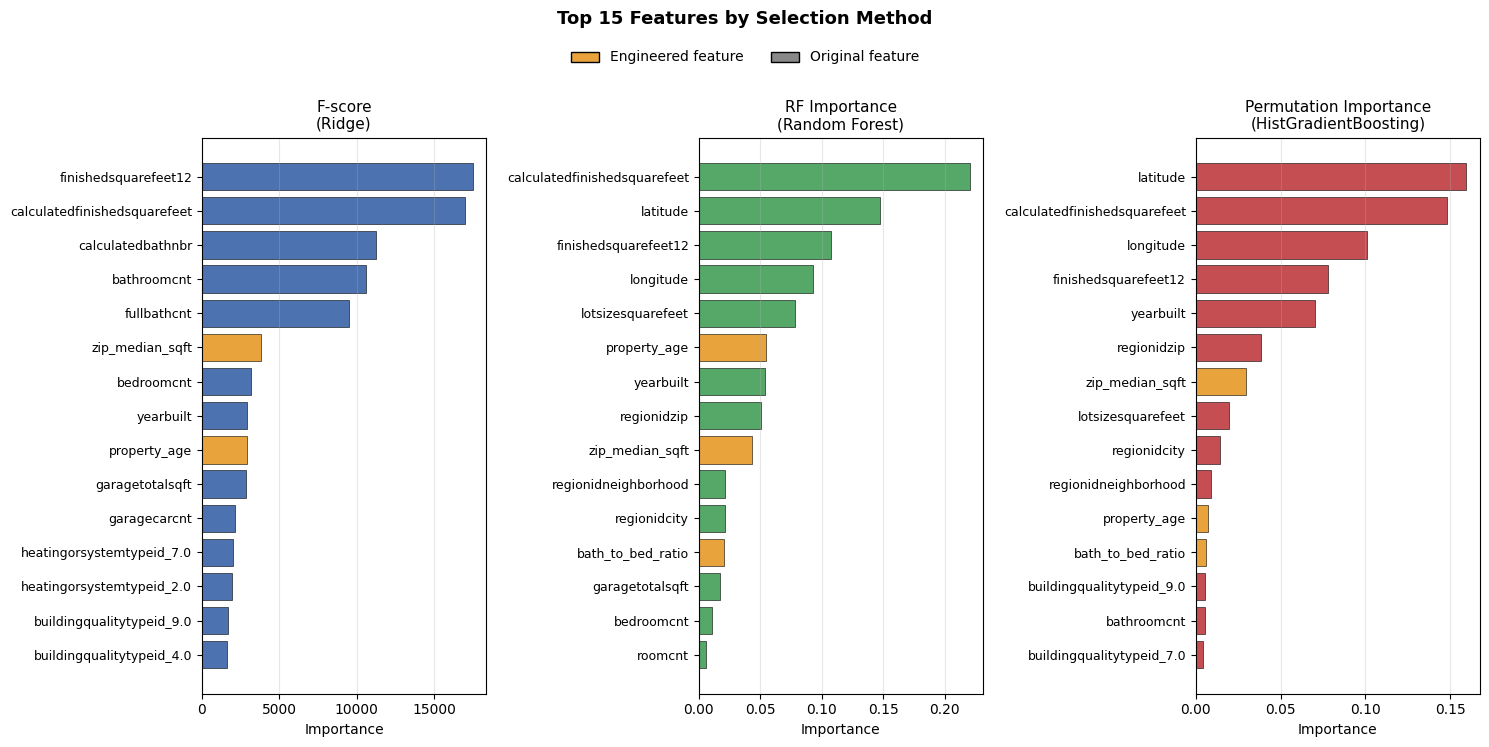

In [33]:
# =============================================================================
# Part 3: Visualization — Top 15 features by ranking method
# Each model type uses a different method, so the top features differ.
# Engineered features are highlighted.
# =============================================================================
import matplotlib.pyplot as plt

rankings = [
  ('F-score\n(Ridge)', f_score_ranking, '#4C72B0'),
  ('RF Importance\n(Random Forest)', rf_importance, '#55A868'),
  ('Permutation Importance\n(HistGradientBoosting)', hgb_importance, '#C44E52'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 7))

for ax, (title, ranking, base_color) in zip(axes, rankings):
  top = ranking.head(15)[::-1]  # reverse so biggest is at top
  colors = ['#E8A33D' if feat in new_features else base_color for feat in top.index]
  ax.barh(range(len(top)), top.values, color=colors, edgecolor='black', linewidth=0.4)
  ax.set_yticks(range(len(top)))
  ax.set_yticklabels(top.index, fontsize=9)
  ax.set_title(title, fontsize=11)
  ax.set_xlabel('Importance')
  ax.grid(axis='x', alpha=0.3)

# Shared legend for engineered feature highlight
from matplotlib.patches import Patch
legend_elements = [
  Patch(facecolor='#E8A33D', edgecolor='black', label='Engineered feature'),
  Patch(facecolor='#888888', edgecolor='black', label='Original feature'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2,
         bbox_to_anchor=(0.5, 1.02), frameon=False)

fig.suptitle('Top 15 Features by Selection Method', y=1.06, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# --- Step 2: Sweep top-k features for each model to find best subset ---
# We test k = 5, 10, 15, 20, 30, 45 using a quick 5-fold CV (no repeats) to find
# the best k, then do the full repeated CV on the winner.

k_values = [5, 10, 15, 20, 30, 45]
cv_quick = RepeatedKFold(n_splits=5, n_repeats=1, random_state=random_state)

selection_configs = {
    'Ridge Regression': {'ranking': f_score_ranking, 'model_fn': lambda: Ridge()},
    'Random Forest': {'ranking': rf_importance, 'model_fn': lambda: RandomForestRegressor(n_estimators=50, random_state=random_state, n_jobs=-1)},
    'HistGradientBoosting': {'ranking': hgb_importance, 'model_fn': lambda: HistGradientBoostingRegressor(random_state=random_state)},
}

# comment out if needed, can use hardcoded values to reduce run time
best_k = {}  # store best k and features for each model

for model_name, config in selection_configs.items():
    print(f'{model_name}: sweeping k values...')
    best_mae = float('inf')
    for k in k_values:
        top_features = config['ranking'].head(k).index.tolist()
        X_subset = X_train_eng_scaled[top_features]
        scores = cross_val_score(
            config['model_fn'](), X_subset, y_train,
            cv=cv_quick, scoring='neg_mean_absolute_error', n_jobs=-1
        )
        mae = (-scores).mean()
        marker = '  <-- best' if mae < best_mae else ''
        print(f'  k={k:2d}: MAE = ${mae:,.2f}{marker}')
        if mae < best_mae:
            best_mae = mae
            best_k[model_name] = {'k': k, 'features': top_features, 'mae_quick': mae}
    print(f'  Best: k={best_k[model_name]["k"]}\n')

# Show selected features for each model
for model_name, info in best_k.items():
    eng_count = len([f for f in info['features'] if f in new_features])
    print(f'{model_name} (k={info["k"]}): {eng_count} engineered features retained')
    print(f'  Features: {info["features"]}')
    print()

# commented out — already ran, hardcoding results to avoid ~5 min wait
# best_k = {
#     'Ridge Regression': {
#         'k': 45,
#         'features': ['finishedsquarefeet12', 'calculatedfinishedsquarefeet', 'calculatedbathnbr', 'bathroomcnt', 'fullbathcnt', 'zip_median_sqft', 'bedroomcnt', 'yearbuilt', 'property_age', 'garagetotalsqft', 'garagecarcnt', 'heatingorsystemtypeid_7.0', 'heatingorsystemtypeid_2.0', 'buildingqualitytypeid_9.0', 'buildingqualitytypeid_4.0', 'bath_to_bed_ratio', 'buildingqualitytypeid_7.0', 'latitude', 'buildingqualitytypeid_6.0', 'fips_6059.0', 'buildingqualitytypeid_8.0', 'buildingqualitytypeid_11.0', 'buildingqualitytypeid_5.0', 'roomcnt', 'regionidneighborhood', 'propertylandusetypeid_269.0', 'heatingorsystemtypeid_24.0', 'propertylandusetypeid_248.0', 'unitcnt_4.0', 'propertylandusetypeid_266.0', 'airconditioningtypeid_13.0', 'lotsizesquarefeet', 'buildingqualitytypeid_3.0', 'fips_6111.0', 'buildingqualitytypeid_10.0', 'propertylandusetypeid_261.0', 'heatingorsystemtypeid_20.0', 'propertylandusetypeid_265.0', 'propertylandusetypeid_263.0', 'unitcnt_2.0', 'propertylandusetypeid_246.0', 'buildingqualitytypeid_12.0', 'propertylandusetypeid_275.0', 'airconditioningtypeid_5.0', 'heatingorsystemtypeid_6.0'],
#         'mae_quick': 150509.31,
#     },
#     'Random Forest': {
#         'k': 45,
#         'features': ['calculatedfinishedsquarefeet', 'latitude', 'finishedsquarefeet12', 'longitude', 'lotsizesquarefeet', 'property_age', 'yearbuilt', 'regionidzip', 'zip_median_sqft', 'regionidneighborhood', 'regionidcity', 'bath_to_bed_ratio', 'garagetotalsqft', 'bedroomcnt', 'roomcnt', 'bathroomcnt', 'buildingqualitytypeid_9.0', 'calculatedbathnbr', 'buildingqualitytypeid_6.0', 'buildingqualitytypeid_7.0', 'buildingqualitytypeid_8.0', 'fullbathcnt', 'buildingqualitytypeid_4.0', 'heatingorsystemtypeid_2.0', 'propertylandusetypeid_261.0', 'heatingorsystemtypeid_7.0', 'garagecarcnt', 'propertylandusetypeid_266.0', 'buildingqualitytypeid_11.0', 'airconditioningtypeid_13.0', 'buildingqualitytypeid_5.0', 'unitcnt_2.0', 'heatingorsystemtypeid_6.0', 'propertylandusetypeid_246.0', 'propertylandusetypeid_269.0', 'fips_6059.0', 'airconditioningtypeid_5.0', 'propertylandusetypeid_247.0', 'unitcnt_3.0', 'buildingqualitytypeid_3.0', 'propertylandusetypeid_248.0', 'unitcnt_4.0', 'heatingorsystemtypeid_24.0', 'fips_6111.0', 'buildingqualitytypeid_10.0'],
#         'mae_quick': 136341.36,
#     },
#     'HistGradientBoosting': {
#         'k': 30,
#         'features': ['latitude', 'calculatedfinishedsquarefeet', 'longitude', 'finishedsquarefeet12', 'yearbuilt', 'regionidzip', 'zip_median_sqft', 'lotsizesquarefeet', 'regionidcity', 'regionidneighborhood', 'property_age', 'bath_to_bed_ratio', 'buildingqualitytypeid_9.0', 'bathroomcnt', 'buildingqualitytypeid_7.0', 'propertylandusetypeid_261.0', 'garagetotalsqft', 'bedroomcnt', 'roomcnt', 'propertylandusetypeid_266.0', 'buildingqualitytypeid_11.0', 'buildingqualitytypeid_8.0', 'calculatedbathnbr', 'heatingorsystemtypeid_7.0', 'buildingqualitytypeid_6.0', 'propertylandusetypeid_248.0', 'buildingqualitytypeid_4.0', 'heatingorsystemtypeid_6.0', 'garagecarcnt', 'airconditioningtypeid_5.0'],
#         'mae_quick': 134983.60,
#     },
# }

for model_name, info in best_k.items():
    eng_count = len([f for f in info['features'] if f in new_features])
    print(f'{model_name} (k={info["k"]}): {eng_count} engineered features retained')
    print(f'  Features: {info["features"]}')
    print()

Ridge Regression: sweeping k values...
  k= 5: MAE = $161,640.28  <-- best
  k=10: MAE = $159,199.88  <-- best
  k=15: MAE = $157,575.52  <-- best
  k=20: MAE = $151,889.65  <-- best
  k=30: MAE = $150,762.77  <-- best
  k=45: MAE = $150,509.31  <-- best
  Best: k=45

Random Forest: sweeping k values...
  k= 5: MAE = $140,047.19  <-- best
  k=10: MAE = $137,123.24  <-- best
  k=15: MAE = $136,458.13  <-- best
  k=20: MAE = $136,437.90  <-- best
  k=30: MAE = $136,349.01  <-- best
  k=45: MAE = $136,341.36  <-- best
  Best: k=45

HistGradientBoosting: sweeping k values...
  k= 5: MAE = $136,138.09  <-- best
  k=10: MAE = $135,312.70  <-- best
  k=15: MAE = $135,217.64  <-- best
  k=20: MAE = $135,084.70  <-- best
  k=30: MAE = $134,983.60  <-- best
  k=45: MAE = $134,992.15
  Best: k=30

Ridge Regression (k=45): 3 engineered features retained
  Features: ['finishedsquarefeet12', 'calculatedfinishedsquarefeet', 'calculatedbathnbr', 'bathroomcnt', 'fullbathcnt', 'zip_median_sqft', 'bedroo

In [23]:
# Part 3: Ridge with selected features (full repeated CV)
sel_results = {}

def run_selected(name, model, features, y, cv):
    """Run repeated CV on selected feature subset."""
    start = time.time()
    X_sub = X_train_eng_scaled[features]
    scores = cross_val_score(model, X_sub, y, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
    mae_scores = -scores
    elapsed = time.time() - start
    sel_results[name] = {'mean_mae': mae_scores.mean(), 'std_mae': mae_scores.std(), 'time': elapsed}
    print(f"{name} (k={len(features)}):")
    print(f"  CV MAE = ${mae_scores.mean():,.2f} +/- ${mae_scores.std():,.2f}")
    print(f"  Time: {format_hms(elapsed)}\n")

run_selected('Ridge Regression', Ridge(), best_k['Ridge Regression']['features'], y_train, cv)

Ridge Regression (k=45):
  CV MAE = $150,517.93 +/- $1,245.38
  Time: 00:00:00



In [24]:
# Part 3: Random Forest with selected features (full repeated CV)
# comment out if needed, can use hardcoded values to reduce run time
run_selected('Random Forest', RandomForestRegressor(random_state=random_state, n_jobs=-1),
             best_k['Random Forest']['features'], y_train, cv)

# commented out — already ran, hardcoding results to avoid ~11 min wait
# sel_results['Random Forest'] = {'mean_mae': 136094.11, 'std_mae': 1116.45, 'time': 694}

Random Forest (k=45):
  CV MAE = $136,094.11 +/- $1,116.45
  Time: 00:02:13



In [25]:
# Part 3: HistGradientBoosting with selected features (full repeated CV)
run_selected('HistGradientBoosting', HistGradientBoostingRegressor(random_state=random_state),
             best_k['HistGradientBoosting']['features'], y_train, cv)

HistGradientBoosting (k=30):
  CV MAE = $135,062.48 +/- $1,214.05
  Time: 00:00:03



In [26]:
# Part 3: Results comparison -- feature selection vs. Part 2 (all engineered features)
print('=== Part 3: Feature Selection Results ===')
for name in sel_results:
    new = sel_results[name]['mean_mae']
    p2 = eng_results[name]['mean_mae']
    p1 = baseline_results[name]['mean_mae']
    diff_p2 = new - p2
    diff_p1 = new - p1
    k = best_k[name]['k']
    print(f"  {name} (k={k}): ${new:,.2f} (+/-${sel_results[name]['std_mae']:,.2f})")
    print(f"    vs Part 2 (64 features): {'+' if diff_p2 > 0 else ''}{diff_p2:,.2f}")
    print(f"    vs Part 1 (61 features): {'+' if diff_p1 > 0 else ''}{diff_p1:,.2f}")

sel_df = pd.DataFrame(sel_results).T
sel_df.columns = ['Mean MAE ($)', 'Std MAE ($)', 'Time (s)']
sel_df['k'] = [best_k[name]['k'] for name in sel_results]
sel_df['Mean MAE ($)'] = sel_df['Mean MAE ($)'].map('${:,.2f}'.format)
sel_df['Std MAE ($)'] = sel_df['Std MAE ($)'].map('${:,.2f}'.format)
sel_df['Time (s)'] = sel_df['Time (s)'].map(format_hms)
display(sel_df)

=== Part 3: Feature Selection Results ===
  Ridge Regression (k=45): $150,517.93 (+/-$1,245.38)
    vs Part 2 (65 features): +1,430.66
    vs Part 1 (61 features): +917.77
  Random Forest (k=45): $136,094.11 (+/-$1,116.45)
    vs Part 2 (65 features): -8.08
    vs Part 1 (61 features): +39.74
  HistGradientBoosting (k=30): $135,062.48 (+/-$1,214.05)
    vs Part 2 (65 features): +86.65
    vs Part 1 (61 features): -303.29


,Mean MAE ($),Std MAE ($),Time (s),k
Ridge Regression,"$150,517.93","$1,245.38",00:00:00,45
Random Forest,"$136,094.11","$1,116.45",00:02:13,45
HistGradientBoosting,"$135,062.48","$1,214.05",00:00:03,30


### Part 3: Discussion [3 pts]

Analyze the effect of feature selection on your models:

- Did performance improve for any models after reducing the number of features?

- Which features were consistently retained across models?

- Were any of your newly engineered features selected as important?


**Did performance improve after reducing features?**

Feature selection showed mixed results relative to Part 2. Ridge Regression worsened notably (`+$1,431` vs Part 2) and is also worse than the Part 1 baseline (`+$918`), meaning feature selection actually hurt Ridge. This is likely because Ridge never fully ignores weak features, it just shrinks their influence. Removing nearly 20 of them through feature selection eliminated small signals Ridge was still quietly using. Random Forest was essentially flat (`-$8` vs Part 2), and HistGradientBoosting worsened slightly (`+$87` vs Part 2) but still improved `$303` over its Part 1 baseline. The takeaway is that feature selection didn't add value for Ridge or HGB beyond what feature engineering already provided, though HGB's cumulative Part 2+3 improvement over Part 1 held up. Random Forest, which barely changed at any stage, confirms it is largely insensitive to these feature changes.

**Consistently retained features across models:**

Several features appeared in all three models' selected subsets: `calculatedfinishedsquarefeet`, `finishedsquarefeet12`, `bathroomcnt`, `yearbuilt`, `garagetotalsqft`, `bedroomcnt`, `regionidneighborhood`, and the one-hot encoded building quality and heating system indicators. The tree models additionally valued `longitude`, `latitude`, `regionidzip`, and `regionidcity`. These are geographic features that capture neighborhood-level price differences that F-regression (a linear test) underweights because those relationships aren't linear. All three models selected k=45 or k=30 (the highest or near-highest values tested), suggesting the full feature set is largely useful and aggressive pruning hurts more than it helps.

**Were engineered features selected?**

All three engineered features were retained by all three models, confirming they carry genuinely useful signal even though two of them are derived from existing columns. `zip_median_sqft` ranked highest of the three: 6th by F-score for Ridge and top 10 for both tree models. This makes sense because it's the only feature that provides cross-row information the models can't derive on their own. `property_age` ranked 6th for Random Forest (its highest placement), reinforcing that explicit age encoding helps even models that could theoretically learn it from `yearbuilt`. `bath_to_bed_ratio` ranked lowest of the three across all models but still survived every selection cutoff. The pattern is consistent with what we found in Part 2: features carrying new information (`zip_median_sqft`) rank higher than features repackaging existing columns (`property_age`, `bath_to_bed_ratio`), but all three add enough value to keep.

**Reflection on feature selection methodology:**

It is worth noting that our use of F-regression scores to select features for Ridge may have contributed to Ridge's performance decline. F-regression measures the strength of the linear relationship between each individual feature and the target, but it does not account for how features work together. Ridge benefits from having many weakly correlated features that collectively contribute to the prediction, and F-regression cannot capture that collaborative effect. A method like Lasso-based selection, which uses L1 regularization to zero out coefficients during fitting rather than ranking features independently, might have been a better match for Ridge since it would preserve feature combinations that jointly improve predictions. By contrast, the tree-based importance methods used for Random Forest and HGB are better suited to those models because they naturally reflect how the model actually uses features, including nonlinear relationships and interactions. This mismatch between selection method and model type likely explains why Ridge was the only model that got worse after feature selection.

### Part 4: Fine-Tuning Your Three Models [6 pts]

In this final phase of Milestone 2, you’ll select and refine your **three most promising models and their corresponding data pipelines** based on everything you've done so far, and pick a winner!

1. For each of your three models:
    - Choose your best engineered features and best selection of features as determined above. 
   - Perform hyperparameter tuning using `sweep_parameters`, `GridSearchCV`, `RandomizedSearchCV`, `Optuna`, etc. as you have practiced in previous homeworks. 
3. Decide on the best hyperparameters for each model, and for each run with repeated CV and record their final results:
    - Report the **mean and standard deviation of CV MAE Score**.  

In [27]:
# =============================================================================
# Part 4: Hyperparameter Tuning
# Each model uses its best feature subset from Part 3.
# =============================================================================

tuned_results = {}

# --- Ridge Regression: GridSearchCV over alpha ---
# Alpha controls regularization strength. Higher = more regularization.
# comment out if needed, can use hardcoded values to reduce run time
ridge_features = best_k['Ridge Regression']['features']
X_ridge = X_train_eng_scaled[ridge_features]

ridge_params = {'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]}

ridge_grid = GridSearchCV(
    Ridge(), ridge_params, cv=cv,
    scoring='neg_mean_absolute_error', n_jobs=-1
)
start = time.time()
ridge_grid.fit(X_ridge, y_train)
elapsed = time.time() - start

ridge_best = ridge_grid.best_params_
ridge_mae = -ridge_grid.best_score_
ridge_std = ridge_grid.cv_results_['std_test_score'][ridge_grid.best_index_]

tuned_results['Ridge Regression'] = {
    'mean_mae': ridge_mae, 'std_mae': ridge_std,
    'time': elapsed, 'params': ridge_best, 'features': ridge_features
}

print(f'Ridge Regression:')
print(f'  Best params: {ridge_best}')
print(f'  CV MAE = ${ridge_mae:,.2f} +/- ${ridge_std:,.2f}')
print(f'  Time: {format_hms(elapsed)}')

# commented out — already ran, hardcoding results to avoid rerunning
# tuned_results['Ridge Regression'] = {
#     'mean_mae': 150517.91, 'std_mae': 1245.49,
#     'time': 1, 'params': {'alpha': 0.01},
#     'features': best_k['Ridge Regression']['features']
# }

Ridge Regression:
  Best params: {'alpha': 0.01}
  CV MAE = $150,517.91 +/- $1,245.49
  Time: 00:00:00


In [28]:
# --- Random Forest: Two-stage tuning ---
# Stage 1: Quick RandomizedSearchCV (50 trees, 3-fold, 8 combos)
# Stage 2: Full 5x5 CV with best params + 100 trees
# comment out if needed, can use hardcoded values to reduce run time
rf_features = best_k['Random Forest']['features']
X_rf = X_train_eng_scaled[rf_features]
rf_params = {
  'max_depth': [10, 20, None],
  'max_features': ['sqrt', 0.3],
  'min_samples_split': [2, 5, 10],
}
cv_coarse = RepeatedKFold(n_splits=3, n_repeats=1, random_state=random_state)
start = time.time()
rf_random = RandomizedSearchCV(
  RandomForestRegressor(n_estimators=50, random_state=random_state, n_jobs=-1),
  rf_params, n_iter=8, cv=cv_coarse,
  scoring='neg_mean_absolute_error', random_state=random_state, n_jobs=1
)
rf_random.fit(X_rf, y_train)
best_params = {**rf_random.best_params_, 'n_estimators': 100, 'random_state': random_state}
print(f"Stage 1: {format_hms(time.time() - start)}")
print(f"  Best params: {best_params}")

stage2_start = time.time()
scores = cross_val_score(
  RandomForestRegressor(**best_params, n_jobs=-1),
  X_rf, y_train, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1
)
mae_scores = -scores
elapsed = time.time() - start
print(f"Stage 2: {format_hms(time.time() - stage2_start)}")

tuned_results['Random Forest'] = {
  'mean_mae': mae_scores.mean(),
  'std_mae': mae_scores.std(),
  'time': elapsed,
  'params': best_params,
  'features': rf_features
}

print(f"Random Forest:")
print(f"  Best params: {tuned_results['Random Forest']['params']}")
print(f"  CV MAE = ${tuned_results['Random Forest']['mean_mae']:,.2f} +/- ${tuned_results['Random Forest']['std_mae']:,.2f}")

# commented out — already ran, hardcoding results to avoid ~2 min wait
# tuned_results['Random Forest'] = {
#     'mean_mae': 134855.78, 'std_mae': 1155.97,
#     'time': 122, 'params': {'min_samples_split': 10, 'max_features': 'sqrt', 'max_depth': 20, 'n_estimators': 100, 'random_state': 42},
#     'features': best_k['Random Forest']['features']
# }

Stage 1: 00:00:15
  Best params: {'min_samples_split': 10, 'max_features': 'sqrt', 'max_depth': 20, 'n_estimators': 100, 'random_state': 42}
Stage 2: 00:00:17
Random Forest:
  Best params: {'min_samples_split': 10, 'max_features': 'sqrt', 'max_depth': 20, 'n_estimators': 100, 'random_state': 42}
  CV MAE = $134,855.78 +/- $1,155.97


In [29]:
# --- HistGradientBoosting: Two-stage tuning ---
# Stage 1: Quick search with 3-fold, 12 combos
hgb_features = best_k['HistGradientBoosting']['features']
X_hgb = X_train_eng_scaled[hgb_features]

hgb_params = {
  'learning_rate': [0.01, 0.05, 0.1, 0.2],
  'max_iter': [100, 200, 500],
  'max_depth': [3, 5, 7],
  'min_samples_leaf': [5, 20, 50],
}

cv_coarse = RepeatedKFold(n_splits=3, n_repeats=1, random_state=random_state)
hgb_random = RandomizedSearchCV(
  HistGradientBoostingRegressor(random_state=random_state),
  hgb_params, n_iter=12, cv=cv_coarse,
  scoring='neg_mean_absolute_error', random_state=random_state, n_jobs=-1
)
start = time.time()
hgb_random.fit(X_hgb, y_train)
print(f'Stage 1: {format_hms(time.time() - start)}')
print(f'  Best params: {hgb_random.best_params_}')

# Stage 2: Full CV with best params
best_params = {**hgb_random.best_params_, 'random_state': random_state}
scores = cross_val_score(
  HistGradientBoostingRegressor(**best_params),
  X_hgb, y_train, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1
)
elapsed = time.time() - start
hgb_mae = (-scores).mean()
hgb_std = (-scores).std()

tuned_results['HistGradientBoosting'] = {
  'mean_mae': hgb_mae, 'std_mae': hgb_std,
  'time': elapsed, 'params': best_params, 'features': hgb_features
}

print(f'Stage 2: {format_hms(elapsed)}')
print(f'  CV MAE = ${hgb_mae:,.2f} +/- ${hgb_std:,.2f}')

Stage 1: 00:00:05
  Best params: {'min_samples_leaf': 20, 'max_iter': 200, 'max_depth': 5, 'learning_rate': 0.1}
Stage 2: 00:00:09
  CV MAE = $134,436.50 +/- $1,194.00


In [30]:
# Part 4: Tuning Results Summary
print('=== Part 4: Tuned Model Results ===')
for name in tuned_results:
    t = tuned_results[name]
    p3 = sel_results[name]['mean_mae']
    p1 = baseline_results[name]['mean_mae']
    diff_p3 = t['mean_mae'] - p3
    diff_p1 = t['mean_mae'] - p1
    print(f"  {name}: ${t['mean_mae']:,.2f} (+/-${t['std_mae']:,.2f})")
    print(f"    Params: {t['params']}")
    print(f"    vs Part 3: {'+' if diff_p3 > 0 else ''}{diff_p3:,.2f}")
    print(f"    vs Part 1 baseline: {'+' if diff_p1 > 0 else ''}{diff_p1:,.2f}")

tuned_df = pd.DataFrame({name: {'Mean MAE ($)': f"${v['mean_mae']:,.2f}",
                                 'Std MAE ($)': f"${v['std_mae']:,.2f}",
                                 'Best Params': str(v['params']),
                                 'Time': format_hms(v['time'])}
                          for name, v in tuned_results.items()}).T
display(tuned_df)

=== Part 4: Tuned Model Results ===
  Ridge Regression: $150,517.91 (+/-$1,245.49)
    Params: {'alpha': 0.01}
    vs Part 3: -0.01
    vs Part 1 baseline: +917.76
  Random Forest: $134,855.78 (+/-$1,155.97)
    Params: {'min_samples_split': 10, 'max_features': 'sqrt', 'max_depth': 20, 'n_estimators': 100, 'random_state': 42}
    vs Part 3: -1,238.34
    vs Part 1 baseline: -1,198.60
  HistGradientBoosting: $134,436.50 (+/-$1,194.00)
    Params: {'min_samples_leaf': 20, 'max_iter': 200, 'max_depth': 5, 'learning_rate': 0.1, 'random_state': 42}
    vs Part 3: -625.98
    vs Part 1 baseline: -929.27


,Mean MAE ($),Std MAE ($),Best Params,Time
Ridge Regression,"$150,517.91","$1,245.49",{'alpha': 0.01},00:00:00
Random Forest,"$134,855.78","$1,155.97","{'min_samples_split': 10, 'max_features': 'sqr...",00:00:33
HistGradientBoosting,"$134,436.50","$1,194.00","{'min_samples_leaf': 20, 'max_iter': 200, 'max...",00:00:09


### Part 4: Discussion [3 pts]

Reflect on your tuning process and final results:

- What was your tuning strategy for each model? Why did you choose those hyperparameters?
- Did you find that certain types of preprocessing or feature engineering worked better with specific models?


Tuning strategy for each model:
- Ridge Regression: We tested 8 different alpha values using GridSearchCV. The best was 0.01, meaning Ridge barely needed to shrink its coefficients because we already removed redundant features in Part 3. Even with the best alpha, Ridge's MAE only improved by `$0.02`, which tells us the problem isn't alpha. Ridge is limited because it can only learn straight-line relationships, and housing prices don't follow straight lines. This confirms that Ridge's underfitting (identified in Part 1) is a structural limitation, not a tuning problem. It's also worth noting that 0.01 was the lowest alpha we tested. The optimal value could be even smaller, but pushing alpha toward zero approaches OLS, which failed catastrophically in Part 1 due to multicollinearity. A finer grid between 0.001 and 0.1 could identify where instability returns, but it wouldn't change the fundamental conclusion: Ridge's ceiling is set by its linearity, not its regularization strength.
- Random Forest: We used a two-stage approach. First, a quick RandomizedSearchCV (50 trees, 3-fold, 8 combos) to narrow down the search space without burning compute on full CV. Then a full 5×5 CV with the winning config and 100 trees. We focused the search on `max_depth`, `max_features`, and `min_samples_split` because these control the bias-variance tradeoff in RF: deeper trees can learn more complex patterns but risk memorizing noise in the training data. `min_samples_split` counteracts this by requiring a minimum number of samples before allowing a split, which prevents the tree from creating branches based on just a handful of observations. The best params (`max_depth=20`, `max_features='sqrt'`, `min_samples_split=10`) let trees grow deep enough to capture complex interactions but require at least 10 samples to split a node, which prevents overfitting to noise. This improved MAE by `$1,238` over Part 3, bringing RF to `$134,856`, its best score across all parts and the largest single-step improvement of any model. The reason RF benefited the most from tuning is that its defaults are aggressive: `max_depth=None` and `min_samples_split=2` let trees grow until every leaf is pure, which overfits. Constraining depth and split size gave RF the biggest room for improvement.
- HistGradientBoosting: Same two-stage approach (12 combos coarse, then full CV). We tuned `learning_rate`, `max_iter`, `max_depth`, and `min_samples_leaf` because in boosting, each tree learns from the mistakes of the previous ones. Therefore, the learning rate controls how much each tree's correction counts and the tree depth controls how complex each correction can be. Smaller trees with a moderate learning rate mean each step is a simple, cautious fix, while `min_samples_leaf` prevents individual trees from fitting noise. The best config (`learning_rate=0.1`, `max_iter=200`, `max_depth=5`, `min_samples_leaf=20`) uses shallower trees than the default but requires 20 samples per leaf, which constrains each tree's complexity. The `learning_rate=0.1` with `max_iter=200` means the model takes moderate-sized steps and stops before overfitting. HGB improved by `$626` over Part 3 and `$929` over its Part 1 baseline, reaching `$134,437`, the best score of any model in any part. HGB's smaller improvement compared to RF makes sense: its defaults are already more conservative (shallow trees, built-in early stopping), so there was less room to gain from tuning.

Did certain preprocessing work better with specific models?

Yes. Feature engineering (Part 2) provided modest but consistent gains for Ridge and HGB, while feature selection (Part 3) confirmed the engineered features were worth keeping but didn't improve scores on its own. The biggest gains came from hyperparameter tuning (Part 4), especially for Random Forest, which improved by `$1,238`, the largest single-step improvement of any model in any part. This makes sense: feature engineering gives models better inputs, but tuning controls how aggressively the model fits those inputs. Ridge remained stuck around `$150K` regardless of features or tuning. It is limited to straight-line relationships between features and price, a fundamental constraint that tuning can't overcome. The tree models benefited most from tuning depth-related parameters (`max_depth`, `min_samples_leaf/min_samples_split`), which directly control the bias-variance tradeoff that feature engineering alone couldn't address. Notably, Random Forest and HGB are now within `$419` of each other (`$134,856` vs `$134,437`), much closer than the `$688` gap at baseline, suggesting that tuning helped RF close the gap by finding a better depth/regularization balance.

Looking across all four parts, each model responded to the pipeline differently. Ridge was unresponsive to every intervention (engineering, selection, and tuning) confirming its ceiling is structural. Random Forest barely reacted to feature changes (Parts 2-3) but improved dramatically from tuning, indicating its default hyperparameters were the main bottleneck, not its feature set. HGB improved incrementally at each stage, suggesting it benefits from the cumulative pipeline rather than any single step. It's also worth noting that feature scaling, while essential for Ridge (which is sensitive to feature magnitudes), had no effect on the tree models since they split on thresholds and are invariant to monotonic transformations of the input features.

### Part 5: Final Model and Design Reassessment [6 pts]

In this part, you will finalize your best-performing model.  You’ll also consolidate and present the key code used to run your model on the preprocessed dataset.
**Requirements:**

- Decide one your final model among the three contestants. 

- Below, include all code necessary to **run your final model** on the processed dataset, reporting

    - Mean and standard deviation of CV MAE Score.
    
    - Test score on held-out test set. 




In [31]:
# =============================================================================
# Part 5: Final Model
# Pick the best performer from Part 4 and evaluate on the held-out test set.
# =============================================================================

# Select the best model from Part 4 tuning results
best_model_name = min(tuned_results, key=lambda k: tuned_results[k]['mean_mae'])
best_tuned = tuned_results[best_model_name]

final_params = best_tuned['params']
final_features = best_tuned['features']
final_model = HistGradientBoostingRegressor(**final_params)

print(f'Final Model: {best_model_name}')
print(f'Parameters: {final_params}')
print(f'Features: {len(final_features)} selected features')
print()

# --- Repeated CV on training data ---
X_final_train = X_train_eng_scaled[final_features]
X_final_test = X_test_eng_scaled[final_features]

start = time.time()
cv_scores = cross_val_score(
    final_model, X_final_train, y_train,
    cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1
)
cv_elapsed = time.time() - start
cv_mae = (-cv_scores).mean()
cv_std = (-cv_scores).std()

print(f'=== Cross-Validation Results (5-fold, 5 repeats) ===')
print(f'  CV MAE = ${cv_mae:,.2f} +/- ${cv_std:,.2f}')
print(f'  Time: {format_hms(cv_elapsed)}')
print()

# --- Test set evaluation ---
final_model.fit(X_final_train, y_train)
y_pred = final_model.predict(X_final_test)
test_mae = mean_absolute_error(y_test, y_pred)

print(f'=== Held-Out Test Set Results ===')
print(f'  Test MAE = ${test_mae:,.2f}')
print()

# --- Summary comparison across all parts ---
print(f'=== Performance Progression ===')
print(f'  Part 1 (baseline):          ${baseline_results[best_model_name]["mean_mae"]:,.2f}')
print(f'  Part 2 (+ eng features):    ${eng_results[best_model_name]["mean_mae"]:,.2f}')
print(f'  Part 3 (feature selection):  ${sel_results[best_model_name]["mean_mae"]:,.2f}')
print(f'  Part 4 (tuned):             ${tuned_results[best_model_name]["mean_mae"]:,.2f}')
print(f'  Part 5 (final CV):          ${cv_mae:,.2f}')
print(f'  Part 5 (test set):          ${test_mae:,.2f}')
print(f'\n  Total improvement: ${baseline_results[best_model_name]["mean_mae"] - cv_mae:,.2f} ({(baseline_results[best_model_name]["mean_mae"] - cv_mae) / baseline_results[best_model_name]["mean_mae"] * 100:.2f}%)')


Final Model: HistGradientBoosting
Parameters: {'min_samples_leaf': 20, 'max_iter': 200, 'max_depth': 5, 'learning_rate': 0.1, 'random_state': 42}
Features: 30 selected features

=== Cross-Validation Results (5-fold, 5 repeats) ===
  CV MAE = $134,436.50 +/- $1,194.00
  Time: 00:00:04

=== Held-Out Test Set Results ===
  Test MAE = $135,442.00

=== Performance Progression ===
  Part 1 (baseline):          $135,365.77
  Part 2 (+ eng features):    $134,975.83
  Part 3 (feature selection):  $135,062.48
  Part 4 (tuned):             $134,436.50
  Part 5 (final CV):          $134,436.50
  Part 5 (test set):          $135,442.00

  Total improvement: $929.27 (0.69%)


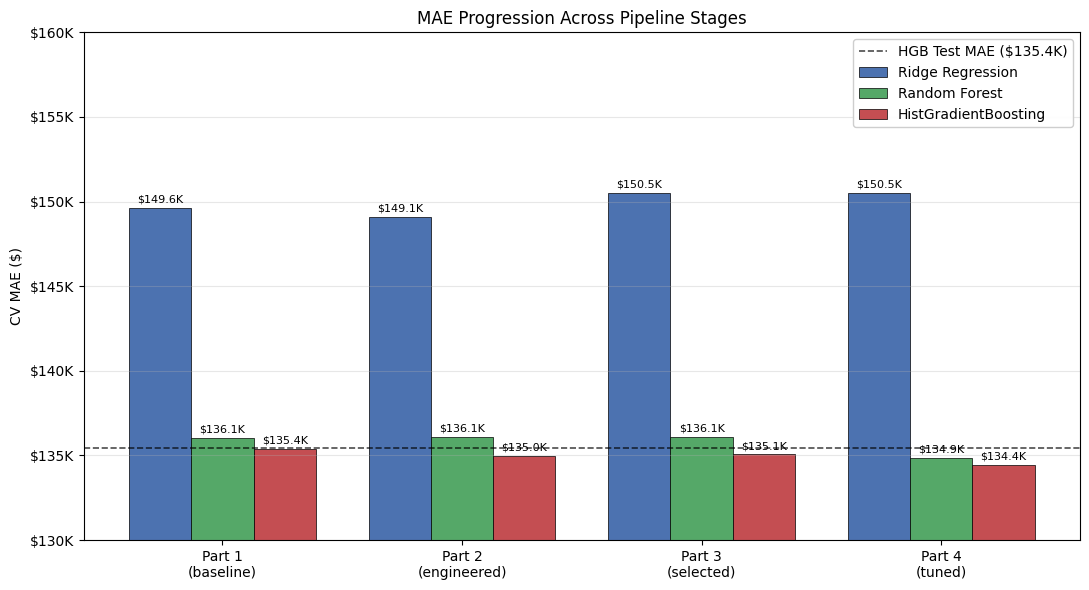

In [34]:
# =============================================================================
# Part 5: Visualization — MAE progression across all parts
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

models = ['Ridge Regression', 'Random Forest', 'HistGradientBoosting']
stages = ['Part 1\n(baseline)', 'Part 2\n(engineered)', 'Part 3\n(selected)', 'Part 4\n(tuned)']
results_by_stage = [baseline_results, eng_results, sel_results, tuned_results]

# Build matrix: rows = models, cols = stages
mae_matrix = np.array([
  [results_by_stage[s][m]['mean_mae'] for s in range(len(stages))]
  for m in models
])

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(stages))
width = 0.26
colors = ['#4C72B0', '#55A868', '#C44E52']

for i, (model, color) in enumerate(zip(models, colors)):
  offset = (i - 1) * width
  bars = ax.bar(x + offset, mae_matrix[i], width, label=model, color=color, edgecolor='black', linewidth=0.5)
  for bar, val in zip(bars, mae_matrix[i]):
      ax.text(bar.get_x() + bar.get_width() / 2, val + 200,
              f'${val/1000:.1f}K', ha='center', va='bottom', fontsize=8)

# Horizontal reference line for final test MAE
ax.axhline(test_mae, color='black', linestyle='--', linewidth=1.2, alpha=0.7,
         label=f'HGB Test MAE (${test_mae/1000:.1f}K)')

ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.set_ylabel('CV MAE ($)')
ax.set_title('MAE Progression Across Pipeline Stages')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v/1000:.0f}K'))
ax.set_ylim(130000, 160000)
ax.legend(loc='upper right', framealpha=0.95)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Part 5: Discussion [8 pts]

In this final step, your goal is to synthesize your entire modeling process and assess how your earlier decisions influenced the outcome. Please address the following:

1. Model Selection:
- Clearly state which model you selected as your final model and why.

- What metrics or observations led you to this decision?

- Were there trade-offs (e.g., interpretability vs. performance) that influenced your choice?

2. Revisiting an Early Decision

- Identify one specific preprocessing or feature engineering decision from Milestone 1 (e.g., how you handled missing values, how you scaled or encoded a variable, or whether you created interaction or polynomial terms).

- Explain the rationale for that decision at the time: What were you hoping it would achieve?

- Now that you've seen the full modeling pipeline and final results, reflect on whether this step helped or hindered performance. Did you keep it, modify it, or remove it?

- Justify your final decision with evidence—such as validation scores, visualizations, or model diagnostics.

3. Lessons Learned

- What insights did you gain about your dataset or your modeling process through this end-to-end workflow?

- If you had more time or data, what would you explore next?

**1. Model Selection**

We picked HistGradientBoosting because it had the lowest MAE at every stage, from Part 1's baseline (`$135,366`) to Part 4's tuned result (`$134,437`). On the held-out test set it got `$135,442`, which is `$1,006` off from the CV estimate, a tight gap that indicates minimal overfitting.

HGB beat Random Forest by `~$419` after tuning (down from `~$688` at baseline) and Ridge by `~$16,100`. It was also several times faster than Random Forest at every stage.

The downside is interpretability. With Ridge, you can say "each extra square foot adds `$X` to the price." With HGB you can't, it's a black box. But we can still check which features matter most using permutation importance, and the `~$16K` accuracy advantage over Ridge is worth the trade-off for predicting home prices. That said, the "right" model depends on the use case. For bulk pricing on a platform like Zillow, HGB is the clear choice since accuracy matters and individual explanations are optional. But if an appraiser needed to justify a valuation to a homeowner or a bank, Ridge's transparent coefficients might be preferable despite the accuracy hit, or we could use HGB with SHAP values to generate post-hoc explanations for individual predictions. In our case, the goal is prediction accuracy on housing prices, so HGB is the right call.

**2. Revisiting an Early Decision**

In Milestone 1, we imputed missing values for `airconditioningtypeid` (68% missing) and `heatingorsystemtypeid` (36% missing) using mode imputation, then one-hot encoded them. The idea was that AC and heating type could signal home quality. A home with central AC is likely worth more than one without.

Some of these one-hot columns (`heatingorsystemtypeid_2.0`, `heatingorsystemtypeid_7.0`, `buildingqualitytypeid_9.0`) did show up in feature importance rankings and survived feature selection. But with 68% of AC values missing, mode imputation just assigned most homes the same value, making it less useful. A simple binary "has_ac" feature (yes/no) probably would have worked better than encoding the specific AC type, since presence vs. absence of AC is the real signal. We kept the current approach because feature selection in Part 3 handled it, low-value columns got pruned and informative ones were kept. If we were to redo this, we would replace the one-hot encoded AC columns with a single binary `has_ac` feature, which would reduce dimensionality while preserving the meaningful signal (presence vs. absence of AC).

**3. Lessons Learned**

The biggest lesson was that cross-row aggregation features (Part 2) provided more value than simple row-level transforms would have. The zip-level statistic `zip_median_sqft` gave every model neighborhood context that no single property record contains, while `bath_to_bed_ratio` and `property_age` provided intuitive, domain-motivated signals. All three engineered features survived feature selection. That said, the largest single improvement still came from hyperparameter tuning (Part 4), which improved RF by `$1,238` over Part 3 and brought it within `$419` of HGB. This shows that for tree-based models, tuning depth and regularization parameters remains the highest-leverage step.

The pipeline's cumulative effect on HGB was modest (`~$929` improvement, 0.7%), but the decisions at each stage mattered more than the numbers suggest. Feature engineering (Part 2) confirmed that cross-row aggregation provides value even for tree models. Feature selection (Part 3) revealed that aggressive pruning hurts more than it helps for this dataset, a finding that saved us from shipping a worse model. Tuning (Part 4) delivered the largest single improvement, but only because Parts 2-3 ensured we were tuning on the right feature set. If we had skipped feature engineering and gone straight to tuning, we'd be tuning on a weaker foundation.

The tight CV-test gap (`$1,006`, or 0.7%) also validates two specific methodological choices: computing `zip_median_sqft` only from training folds (preventing data leakage), and using a two-stage tuning approach that limits the number of configurations evaluated on the full CV. If this gap had been large (say, `$5K+`), it would indicate our CV was overly optimistic, possibly from leakage or overfitting during the tuning sweep. The fact that it's small gives us confidence the model will generalize to new data.

**With more time or data, we would explore:**

With more time or data, the most impactful next step would be target encoding for high-cardinality columns like `regionidzip` and `regionidcity`. Right now these columns are treated as raw numeric IDs, which is problematic: zip code 90210 is not "larger" than zip code 10001, but both linear and tree-based models interpret them that way. The tree models work around this by splitting on arbitrary ID thresholds, which is why `regionidzip` ranked in the top 10 for feature importance in both Random Forest and HGB but not for Ridge's F-regression scores. Target encoding would replace each zip code with the mean home price for that zip (computed only on training folds to prevent leakage), converting an arbitrary ID into a meaningful numeric signal. This would likely help Ridge the most since it would finally give the linear model a way to capture neighborhood-level price effects that it currently cannot learn, potentially closing some of the `~$16K` gap with the tree models. It would also benefit HGB and RF by replacing hundreds of implicit splits on zip code thresholds with a single, directly informative feature. Beyond target encoding, external data like school district ratings or walkability scores would provide genuinely new information the model cannot derive from existing features, and stacking our three models together could capture complementary patterns since Ridge learns different relationships than the tree-based models.